# Advanced Unsupervised Machine Learning & Model Interpretation

## Setup

### Imports

In [78]:
# imports
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import euclidean, cityblock, cosine, pdist

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import train_test_split
import shap

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
np.random.seed(42)
print("All libraries imported successfully!")

All libraries imported successfully!


# Download Datasets

In [79]:
# download datasets

path_customers = kagglehub.dataset_download(
    "binovi/wholesale-customers-data-set"
)

path_faces = kagglehub.dataset_download(
    "sahilyagnik/olivetti-faces"
)

print("Wholesale Customers Dataset:", path_customers)
print("Olivetti Faces Dataset:", path_faces)

Wholesale Customers Dataset: C:\Users\NR\.cache\kagglehub\datasets\binovi\wholesale-customers-data-set\versions\1
Olivetti Faces Dataset: C:\Users\NR\.cache\kagglehub\datasets\sahilyagnik\olivetti-faces\versions\1


# Part 1: Clustering Dataset (Wholesale Customers)

# Load Dataset

In [80]:
# Load data

df1 = pd.read_csv(os.path.join(path_customers, "Wholesale customers data.csv"))
df1.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [81]:
import os

print(os.listdir(path_customers))

['Wholesale customers data.csv']


In [82]:
# basic info

df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [83]:
# summary stats

df1.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [84]:
# check missing values

df1.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

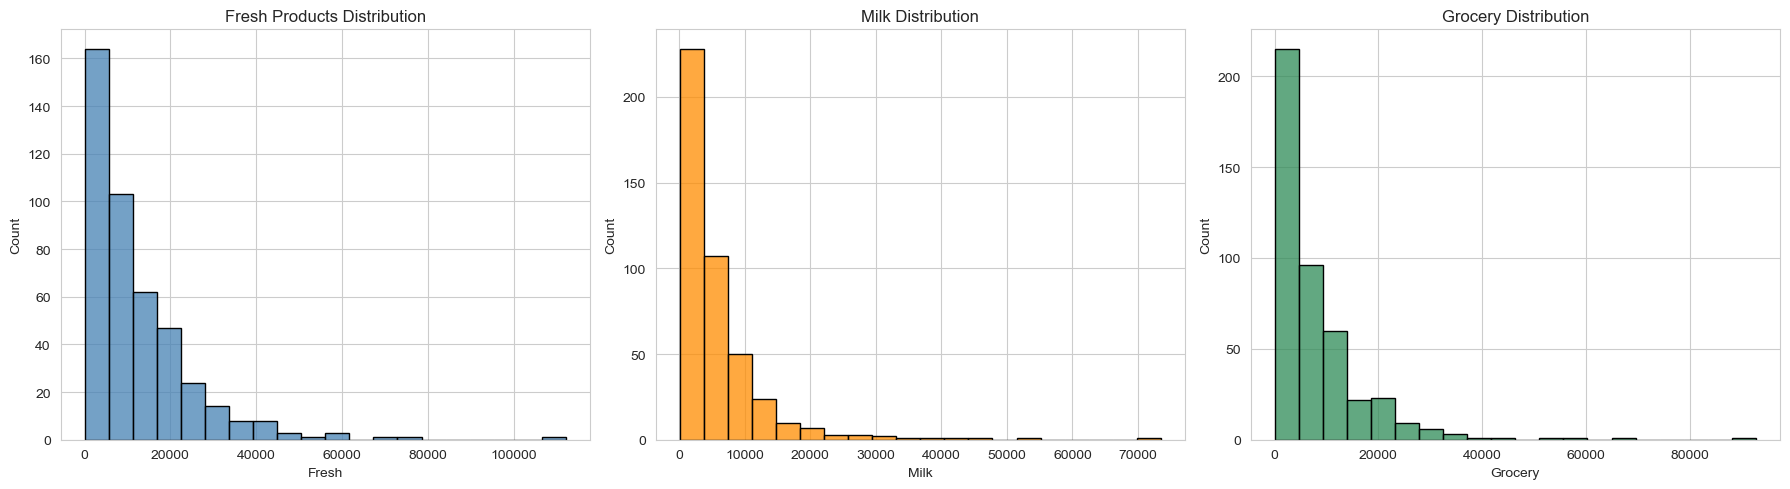

In [85]:
# distributions

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    df1["Fresh"],
    bins=20,
    color="steelblue",
    edgecolor="black",
    ax=axes[0]
)
axes[0].set_title("Fresh Products Distribution")
axes[0].set_xlabel("Fresh")

sns.histplot(
    df1["Milk"],
    bins=20,
    color="darkorange",
    edgecolor="black",
    ax=axes[1]
)
axes[1].set_title("Milk Distribution")
axes[1].set_xlabel("Milk")

sns.histplot(
    df1["Grocery"],
    bins=20,
    color="seagreen",
    edgecolor="black",
    ax=axes[2]
)
axes[2].set_title("Grocery Distribution")
axes[2].set_xlabel("Grocery")

plt.tight_layout()
plt.show()

In [86]:
# select features

features = ["Fresh", "Milk", "Grocery"]

X = df1[features].copy()

X.head()

,Fresh,Milk,Grocery
0,12669,9656,7561
1,7057,9810,9568
2,6353,8808,7684
3,13265,1196,4221
4,22615,5410,7198


# Distance Metrics

In [87]:
# distance metric example

a = X.iloc[0].values
b = X.iloc[1].values

print("Euclidean Distance :", euclidean(a, b))
print("Manhattan Distance:", cityblock(a, b))
print("Cosine Distance   :", cosine(a, b))

Euclidean Distance : 5962.072542329554
Manhattan Distance: 7773
Cosine Distance   : 0.05633632755809981


# Feature Scaling

In [88]:
# scale features

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=features
)

X_scaled.head()

,Fresh,Milk,Grocery
0,0.052933,0.523568,-0.041115
1,-0.391302,0.544458,0.170318
2,-0.447029,0.408538,-0.028157
3,0.100111,-0.624020,-0.392977
4,0.840239,-0.052396,-0.079356


# Curse of Dimensionality

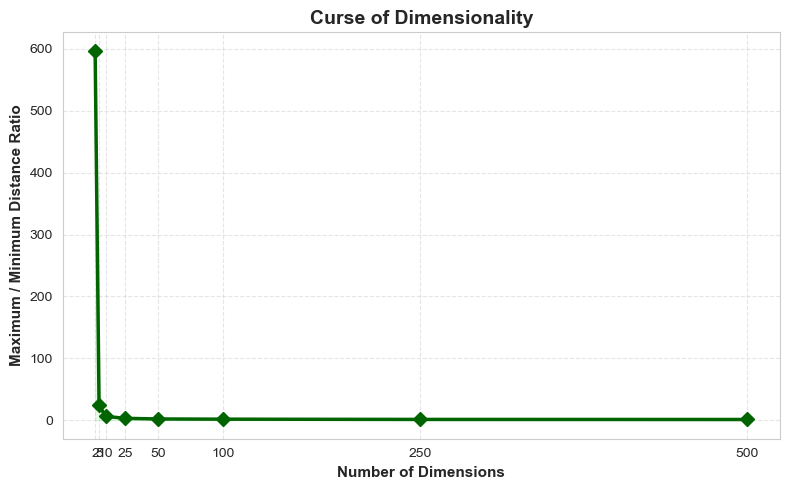

In [89]:
# curse of dimensionality demo

dims = [2, 5, 10, 25, 50, 100, 250, 500]
ratios = []

for d in dims:
    pts = np.random.rand(300, d)
    dist = pdist(pts)

    ratio = dist.max() / dist.min()
    ratios.append(ratio)

plt.figure(figsize=(8, 5))

plt.plot(
    dims,
    ratios,
    marker="D",
    markersize=7,
    linewidth=2.5,
    color="darkgreen"
)

plt.fill_between(
    dims,
    ratios,
    alpha=0.20,
    color="lightgreen"
)

plt.xlabel("Number of Dimensions", fontsize=11, fontweight="bold")
plt.ylabel("Maximum / Minimum Distance Ratio", fontsize=11, fontweight="bold")
plt.title("Curse of Dimensionality", fontsize=14, fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(dims)
plt.tight_layout()
plt.show()

# PCA and t-SNE vs UMAP (quick preview)

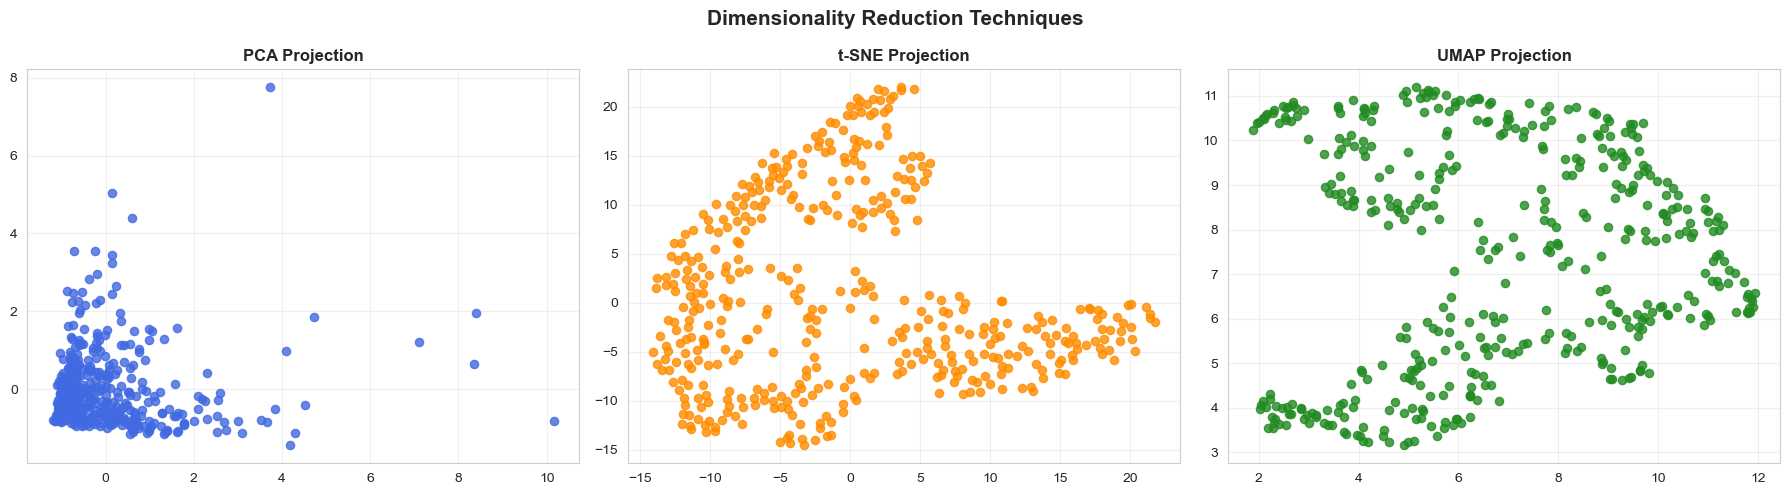

In [90]:
# PCA, t-SNE and UMAP visualization

pca_demo = PCA(n_components=2)
pca_res = pca_demo.fit_transform(X_scaled)

tsne_demo = TSNE(
    n_components=2,
    perplexity=40,
    random_state=42
)
tsne_res = tsne_demo.fit_transform(X_scaled)

umap_demo = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.2,
    random_state=42
)
umap_res = umap_demo.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
axes[0].scatter(
    pca_res[:, 0],
    pca_res[:, 1],
    c="royalblue",
    s=35,
    alpha=0.8
)
axes[0].set_title("PCA Projection", fontsize=12, fontweight="bold")
axes[0].grid(alpha=0.3)

# t-SNE
axes[1].scatter(
    tsne_res[:, 0],
    tsne_res[:, 1],
    c="darkorange",
    s=35,
    alpha=0.8
)
axes[1].set_title("t-SNE Projection", fontsize=12, fontweight="bold")
axes[1].grid(alpha=0.3)

# UMAP
axes[2].scatter(
    umap_res[:, 0],
    umap_res[:, 1],
    c="forestgreen",
    s=35,
    alpha=0.8
)
axes[2].set_title("UMAP Projection", fontsize=12, fontweight="bold")
axes[2].grid(alpha=0.3)

plt.suptitle(
    "Dimensionality Reduction Techniques",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Clustering Algorithms

# K-Means

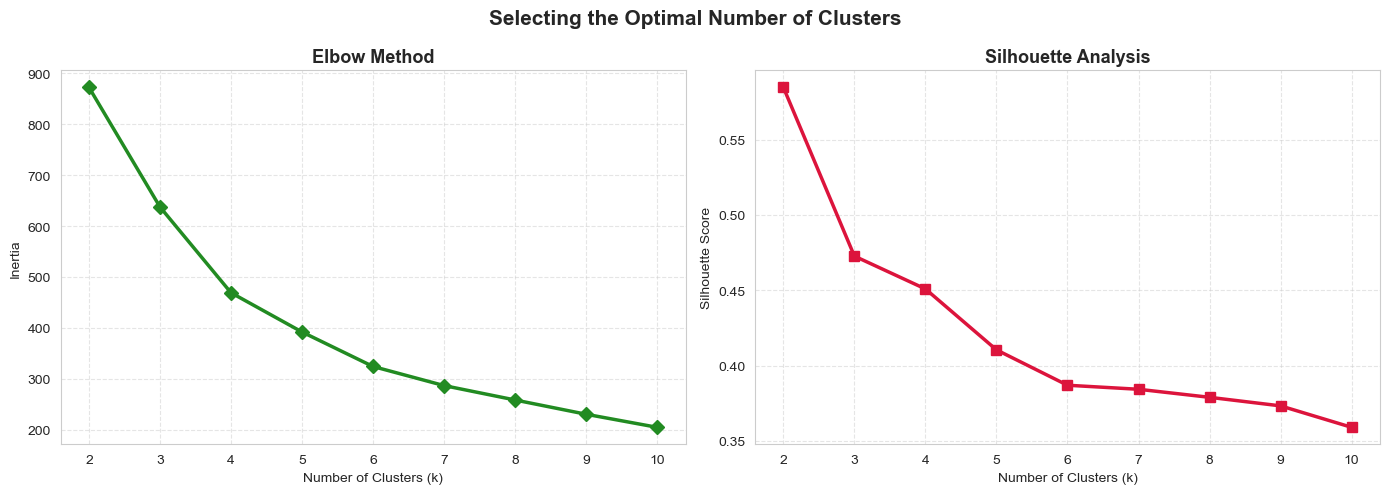

In [91]:
# Elbow Method and Silhouette Score

inertias = []
sil_scores = []

K_range = range(2, 11)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Elbow Plot
axes[0].plot(
    list(K_range),
    inertias,
    marker="D",
    markersize=7,
    linewidth=2.5,
    color="forestgreen"
)
axes[0].set_title("Elbow Method", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Silhouette Plot
axes[1].plot(
    list(K_range),
    sil_scores,
    marker="s",
    markersize=7,
    linewidth=2.5,
    color="crimson"
)
axes[1].set_title("Silhouette Analysis", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle(
    "Selecting the Optimal Number of Clusters",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [92]:
# fit KMeans with best k

best_k = list(K_range)[np.argmax(sil_scores)]

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

labels_kmeans = kmeans.fit_predict(X_scaled)

df1["KMeans_Cluster"] = labels_kmeans

print("Optimal Number of Clusters:", best_k)

Optimal Number of Clusters: 2


In [93]:
# report inertia

print(f"K-Means Inertia: {kmeans.inertia_:.2f}")

K-Means Inertia: 872.38


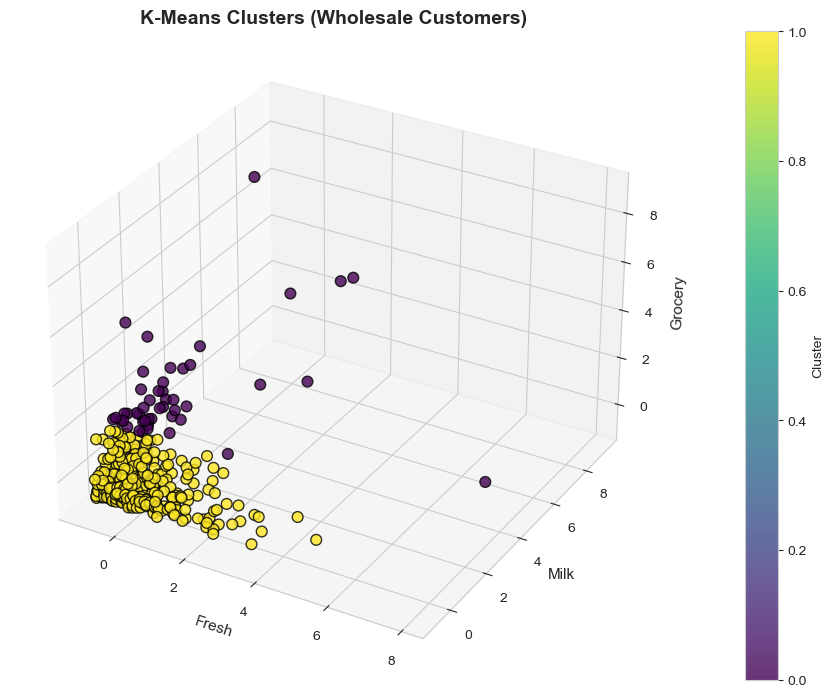

In [94]:
# visualize KMeans clusters

fig = plt.figure(figsize=(9,7))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_scaled["Fresh"],
    X_scaled["Milk"],
    X_scaled["Grocery"],
    c=labels_kmeans,
    cmap="viridis",
    s=60,
    alpha=0.8,
    edgecolor="black"
)

ax.set_xlabel("Fresh", fontsize=11)
ax.set_ylabel("Milk", fontsize=11)
ax.set_zlabel("Grocery", fontsize=11)

ax.set_title(
    "K-Means Clusters (Wholesale Customers)",
    fontsize=14,
    fontweight="bold"
)

plt.colorbar(scatter, pad=0.1, label="Cluster")

plt.tight_layout()
plt.show()

# Hierarchical Clustering

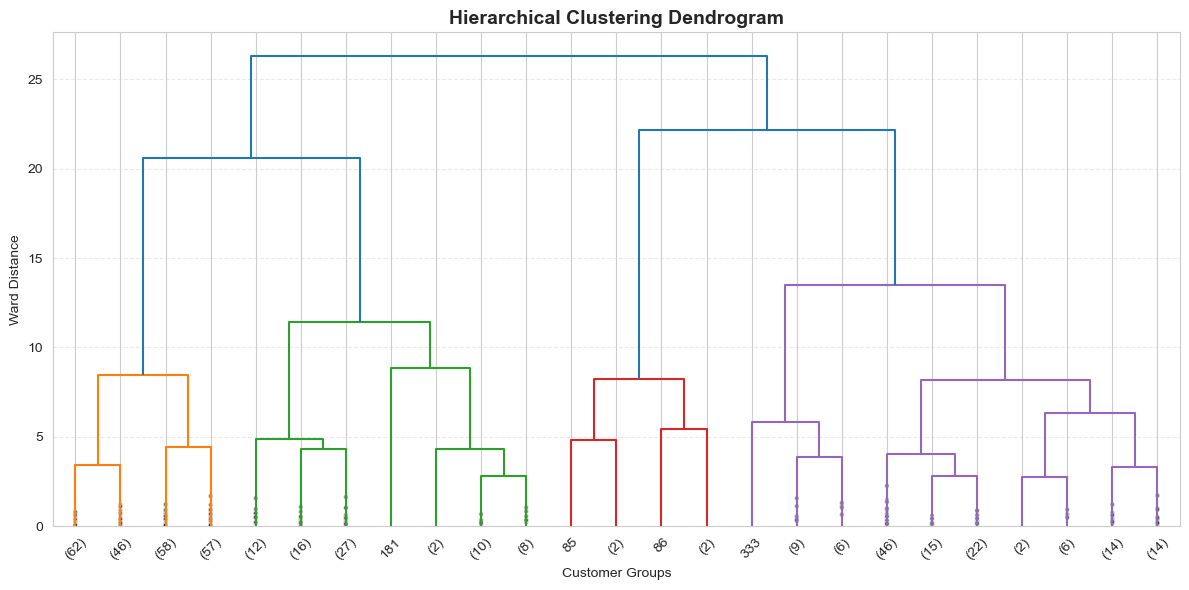

In [95]:
# dendrogram

linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=25,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)

plt.title(
    "Hierarchical Clustering Dendrogram",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Customer Groups")
plt.ylabel("Ward Distance")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [96]:
# fit agglomerative clustering

agg = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

labels_agg = agg.fit_predict(X_scaled)

df1["Agg_Cluster"] = labels_agg

print("Agglomerative clustering completed.")
print("Number of clusters:", len(np.unique(labels_agg)))

Agglomerative clustering completed.
Number of clusters: 2


## DBSCAN

In [97]:
# tune dbscan

eps_range = np.arange(0.3, 1.6, 0.1)
min_samples_range = range(3, 11)

best_score = -1
best_params = None

for eps, ms in product(eps_range, min_samples_range):

    db = DBSCAN(
        eps=eps,
        min_samples=ms
    )

    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters > 1:
        try:
            score = silhouette_score(X_scaled, labels)

            if score > best_score:
                best_score = score
                best_params = (eps, ms)

        except Exception:
            continue

print("Best Parameters :", best_params)
print("Best Silhouette Score :", round(best_score, 4))

Best Parameters : (np.float64(0.8000000000000003), 6)
Best Silhouette Score : 0.4551


In [98]:
# fit dbscan with best parameters

dbscan = DBSCAN(
    eps=best_params[0],
    min_samples=best_params[1]
)

labels_dbscan = dbscan.fit_predict(X_scaled)

df1["DBSCAN_Cluster"] = labels_dbscan

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)

print("Clusters Found :", n_clusters)
print("Noise Points :", (labels_dbscan == -1).sum())

Clusters Found : 2
Noise Points : 21


## Gaussian Mixture Models (GMM)

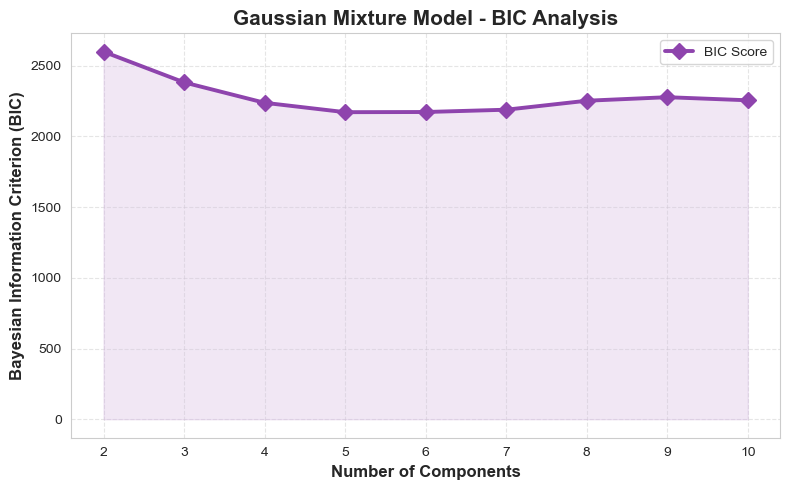

In [99]:
# tune gmm using bic

bics = []

n_range = range(2, 11)

for n in n_range:

    gmm = GaussianMixture(
        n_components=n,
        random_state=42
    )

    gmm.fit(X_scaled)

    bics.append(gmm.bic(X_scaled))

plt.figure(figsize=(8,5))

plt.plot(
    list(n_range),
    bics,
    marker="D",
    markersize=8,
    linewidth=2.8,
    color="#8E44AD",
    label="BIC Score"
)

plt.fill_between(
    list(n_range),
    bics,
    color="#D7BDE2",
    alpha=0.35
)

plt.xticks(list(n_range))

plt.title(
    "Gaussian Mixture Model - BIC Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Number of Components",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Bayesian Information Criterion (BIC)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()

plt.tight_layout()
plt.show()

In [100]:
# fit gmm with best number of components

best_n = list(n_range)[np.argmin(bics)]

gmm = GaussianMixture(
    n_components=best_n,
    random_state=42
)

labels_gmm = gmm.fit_predict(X_scaled)

df1["gmm_cluster"] = labels_gmm

print("Best Number of Components:", best_n)
print("Lowest BIC Score:", round(min(bics), 2))

Best Number of Components: 5
Lowest BIC Score: 2171.93


## Mean Shift

In [101]:
# fit mean shift

bandwidth = estimate_bandwidth(
    X_scaled,
    quantile=0.25,
    n_samples=len(X_scaled),
    random_state=42
)

ms_model = MeanShift(
    bandwidth=bandwidth,
    bin_seeding=True
)

labels_ms = ms_model.fit_predict(X_scaled)

df1["MeanShift_Cluster"] = labels_ms

n_ms_clusters = len(np.unique(labels_ms))

print("Estimated Bandwidth:", round(bandwidth, 4))
print("Clusters Found:", n_ms_clusters)

Estimated Bandwidth: 1.1722
Clusters Found: 10


## Cluster Evaluation and Comparison

In [102]:
# compare clustering algorithms

algo_labels = {
    "K-Means": labels_kmeans,
    "Hierarchical": labels_agg,
    "DBSCAN": labels_dbscan,
    "GMM": labels_gmm,
    "Mean Shift": labels_ms
}

results = []

for name, labels in algo_labels.items():

    unique_labels = set(labels)

    # Remove DBSCAN noise label from cluster count
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    # Use only non-noise points for DBSCAN evaluation
    if name == "DBSCAN":
        valid_mask = labels != -1
        X_eval = X_scaled.loc[valid_mask]
        labels_eval = labels[valid_mask]
    else:
        X_eval = X_scaled
        labels_eval = labels

    if len(np.unique(labels_eval)) > 1:
        silhouette = silhouette_score(X_eval, labels_eval)
        davies_bouldin = davies_bouldin_score(X_eval, labels_eval)
        calinski_harabasz = calinski_harabasz_score(X_eval, labels_eval)
    else:
        silhouette = np.nan
        davies_bouldin = np.nan
        calinski_harabasz = np.nan

    results.append([
        name,
        n_clusters,
        silhouette,
        davies_bouldin,
        calinski_harabasz
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Clusters",
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz"
    ]
)

results_df.round(4)

,Algorithm,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,2,0.5847,0.9412,224.7408
1,Hierarchical,2,0.3549,1.2197,155.6022
2,DBSCAN,2,0.4951,0.5199,22.7199
3,GMM,5,0.2139,1.4322,121.3963
4,Mean Shift,10,0.4633,0.4773,88.7119


## Comparison of Clustering Algorithms

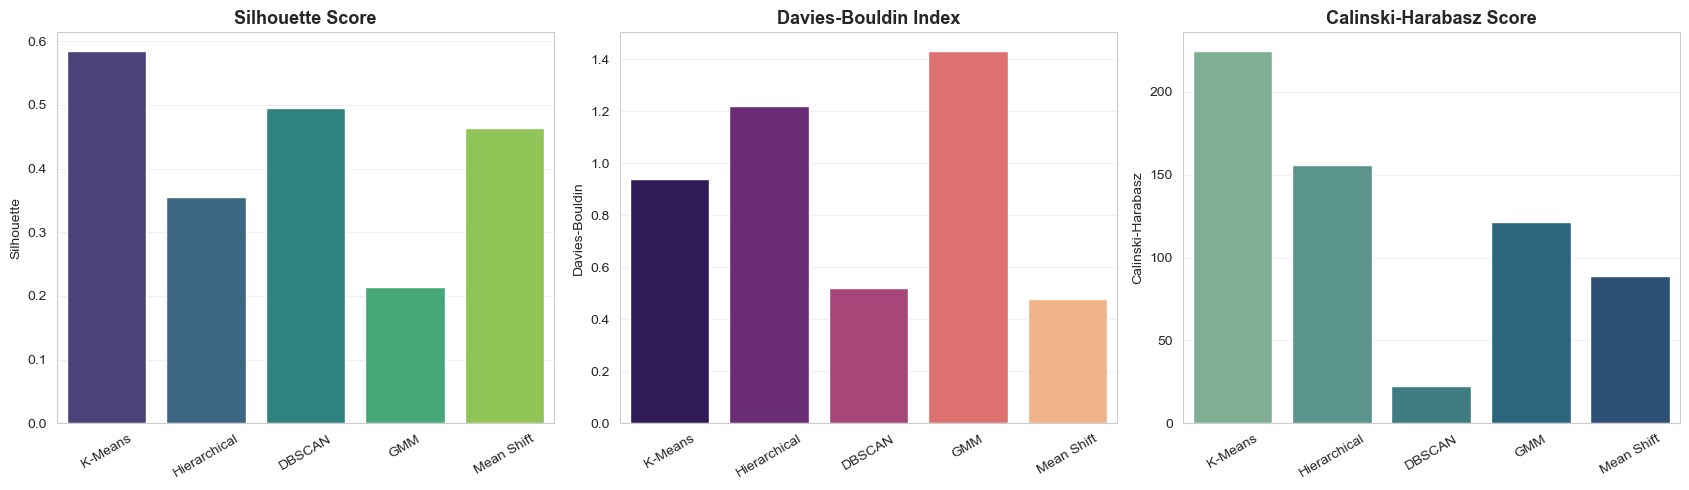

In [103]:
# compare clustering performance visually

fig, axes = plt.subplots(1, 3, figsize=(17,5))

# Silhouette Score
sns.barplot(
    data=results_df,
    x="Algorithm",
    y="Silhouette",
    hue="Algorithm",
    palette="viridis",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Silhouette Score", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].grid(axis="y", alpha=0.3)

# Davies-Bouldin
sns.barplot(
    data=results_df,
    x="Algorithm",
    y="Davies-Bouldin",
    hue="Algorithm",
    palette="magma",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Davies-Bouldin Index", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].grid(axis="y", alpha=0.3)

# Calinski-Harabasz
sns.barplot(
    data=results_df,
    x="Algorithm",
    y="Calinski-Harabasz",
    hue="Algorithm",
    palette="crest",
    legend=False,
    ax=axes[2]
)
axes[2].set_title("Calinski-Harabasz Score", fontsize=13, fontweight="bold")
axes[2].set_xlabel("")
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [104]:
# best clustering algorithm

best_algo = results_df.loc[
    results_df["Silhouette"].idxmax(),
    "Algorithm"
]

best_score = results_df["Silhouette"].max()

print("="*40)
print("Best Clustering Algorithm :", best_algo)
print("Silhouette Score          :", round(best_score,4))
print("DBSCAN Noise Points       :", (labels_dbscan == -1).sum())
print("="*40)

Best Clustering Algorithm : K-Means
Silhouette Score          : 0.5847
DBSCAN Noise Points       : 21


## Visualization of Clustering Results

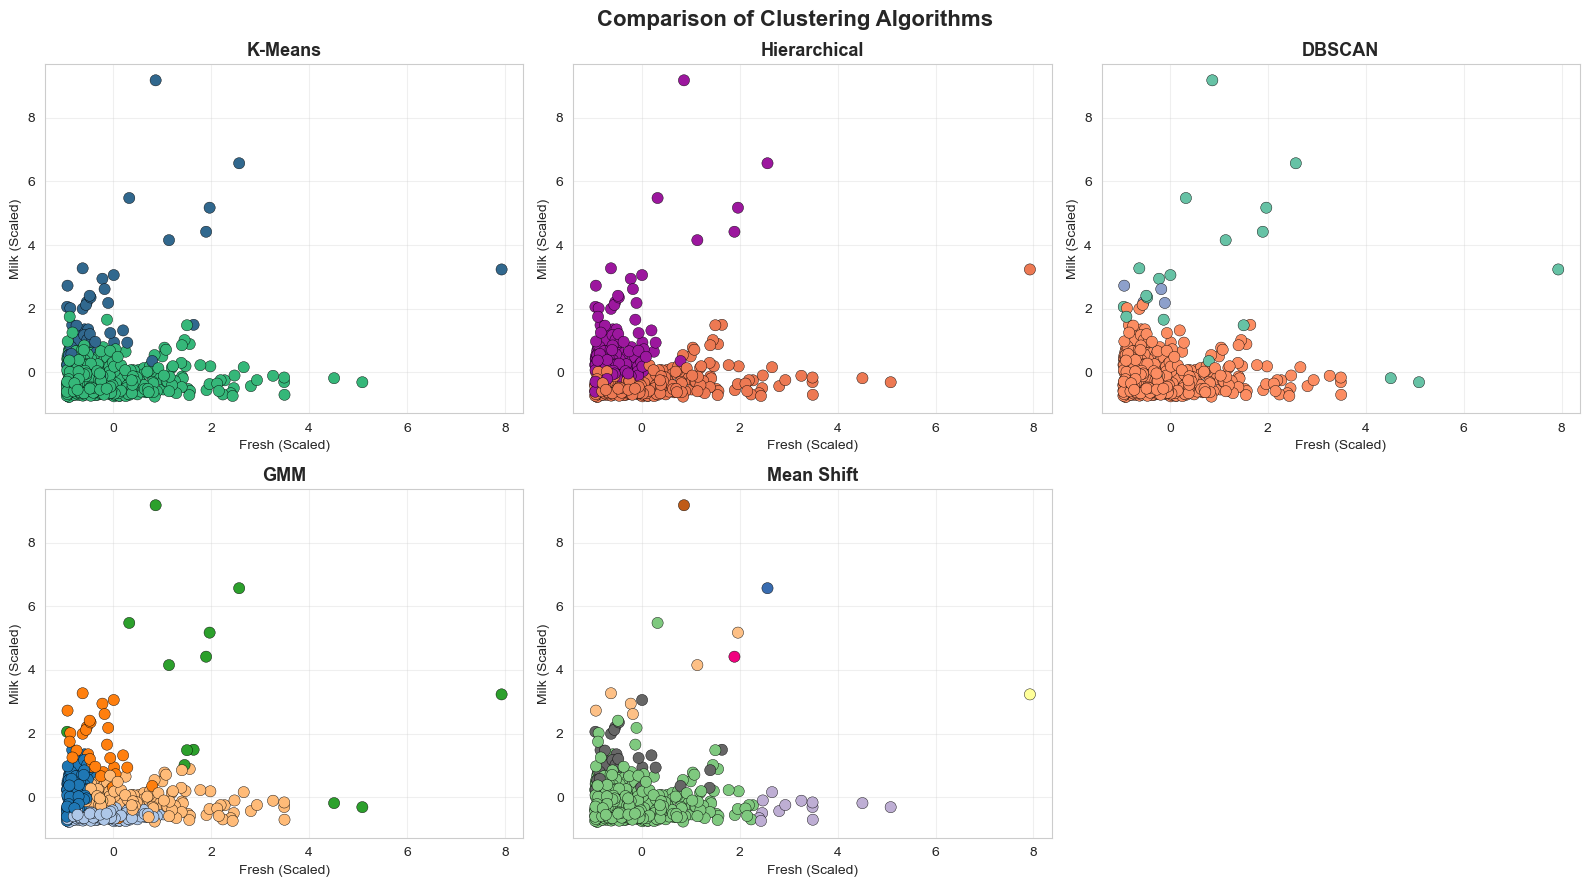

In [105]:
# visualize all clustering results

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes = axes.ravel()

colors = ["viridis", "plasma", "Set2", "tab20", "Accent"]

for i, (name, labels) in enumerate(algo_labels.items()):

    sns.scatterplot(
        x=X_scaled["Fresh"],
        y=X_scaled["Milk"],
        hue=labels,
        palette=colors[i],
        s=65,
        edgecolor="black",
        linewidth=0.3,
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(
        name,
        fontsize=13,
        fontweight="bold"
    )

    axes[i].set_xlabel("Fresh (Scaled)")
    axes[i].set_ylabel("Milk (Scaled)")

    axes[i].grid(alpha=0.3)

# Hide last subplot if unused
axes[-1].axis("off")

plt.suptitle(
    "Comparison of Clustering Algorithms",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Clustering After PCA (Wholesale Customers Dataset)

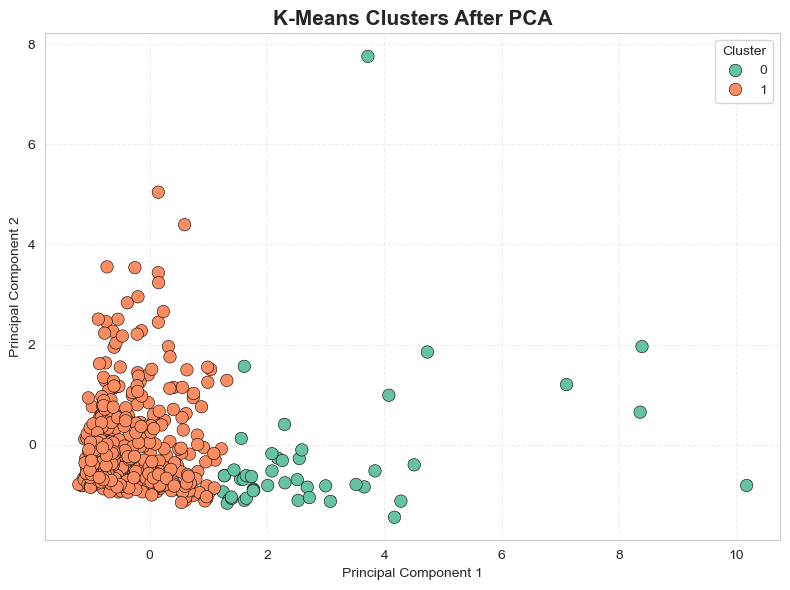

In [106]:
# PCA for Wholesale Customers Dataset

pca_wholesale = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca_wholesale.fit_transform(X_scaled)

# Apply K-Means after PCA

kmeans_pca = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

labels_pca = kmeans_pca.fit_predict(X_pca)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=labels_pca,
    palette="Set2",
    s=80,
    edgecolor="black",
    linewidth=0.4
)

plt.title(
    "K-Means Clusters After PCA",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3, linestyle="--")

plt.legend(title="Cluster")

plt.tight_layout()

plt.show()

## PCA Performance Comparison

In [107]:
# compare silhouette score before and after PCA

sil_before_pca = silhouette_score(X_scaled, labels_kmeans)
sil_after_pca = silhouette_score(X_pca, labels_pca)

print("="*45)
print("Silhouette Score Before PCA :", round(sil_before_pca, 4))
print("Silhouette Score After PCA  :", round(sil_after_pca, 4))
print("="*45)

Silhouette Score Before PCA : 0.5847
Silhouette Score After PCA  : 0.5966


## Preprocessing Experiment

In [108]:
# compare different scaling techniques

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

scaler_results = []

for name, scaler in scalers.items():

    X_temp = scaler.fit_transform(X)

    km = KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_temp)

    score = silhouette_score(X_temp, labels)

    scaler_results.append([name, score])

scaler_results_df = pd.DataFrame(
    scaler_results,
    columns=["Scaler", "Silhouette Score"]
)

scaler_results_df

,Scaler,Silhouette Score
0,StandardScaler,0.584655
1,MinMaxScaler,0.570048


In [109]:
# compare multiple preprocessing methods

from sklearn.preprocessing import RobustScaler

scalers2 = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "No Scaling": None
}

scaler_results2 = []

for name, scaler in scalers2.items():

    if scaler is None:
        X_temp = X.values
    else:
        X_temp = scaler.fit_transform(X)

    km = KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_temp)

    score = silhouette_score(X_temp, labels)

    scaler_results2.append([name, score])

scaler_results2_df = pd.DataFrame(
    scaler_results2,
    columns=["Scaler", "Silhouette Score"]
)

scaler_results2_df

,Scaler,Silhouette Score
0,StandardScaler,0.584655
1,MinMaxScaler,0.570048
2,RobustScaler,0.641096
3,No Scaling,0.529735


# Part 2: High-Dimensional Dataset (Olivetti Faces)

# Load Data

In [110]:
# load Olivetti Faces dataset

from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces(shuffle=True, random_state=42)

X2_raw = pd.DataFrame(olivetti.data)

y2_raw = pd.DataFrame(
    olivetti.target,
    columns=["Person_ID"]
)

print("Dataset Shape:", X2_raw.shape)

X2_raw.head()

Dataset Shape: (400, 4096)


,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,0.198347,0.235537,0.351240,0.409091,0.421488,0.429752,0.500000,0.528926,0.524793,0.553719,...,0.528926,0.508264,0.524793,0.504132,0.483471,0.471074,0.285124,0.061983,0.128099,0.090909
1,0.185950,0.128099,0.115702,0.132231,0.185950,0.268595,0.433884,0.541322,0.570248,0.586777,...,0.400826,0.396694,0.409091,0.301653,0.421488,0.462810,0.247934,0.190083,0.210744,0.210744
2,0.508264,0.603306,0.619835,0.628099,0.657025,0.665289,0.690083,0.727273,0.743802,0.768595,...,0.438017,0.301653,0.305785,0.314050,0.326446,0.338843,0.330579,0.334711,0.342975,0.342975
3,0.136364,0.140496,0.185950,0.280992,0.318182,0.363636,0.409091,0.417355,0.438017,0.454545,...,0.198347,0.169421,0.206612,0.276859,0.355372,0.685950,0.661157,0.280992,0.371901,0.276859
4,0.652893,0.644628,0.652893,0.706612,0.714876,0.719008,0.743802,0.747934,0.747934,0.756198,...,0.061983,0.074380,0.074380,0.082645,0.082645,0.111570,0.070248,0.086777,0.185950,0.231405


In [111]:
# check target classes

y2_raw["Person_ID"].value_counts().sort_index()

Person_ID
0     10
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8     10
9     10
10    10
11    10
12    10
13    10
14    10
15    10
16    10
17    10
18    10
19    10
20    10
21    10
22    10
23    10
24    10
25    10
26    10
27    10
28    10
29    10
30    10
31    10
32    10
33    10
34    10
35    10
36    10
37    10
38    10
39    10
Name: count, dtype: int64

# Merge and check dimensions

In [112]:
# samples vs features

n_samples, n_features = X2_raw.shape

print("Samples :", n_samples)
print("Features :", n_features)
print("Features per Sample :", round(n_features / n_samples, 2))

Samples : 400
Features : 4096
Features per Sample : 10.24


In [113]:
# check missing values

print("Total Missing Values :", X2_raw.isnull().sum().sum())

Total Missing Values : 0


### Encode Target

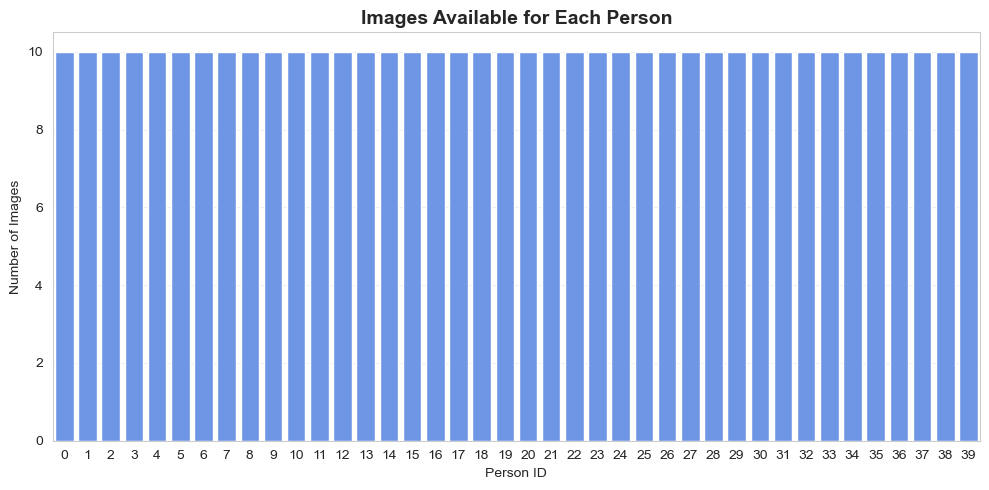

In [114]:
# target distribution

y2 = y2_raw["Person_ID"].copy()

plt.figure(figsize=(10,5))

sns.countplot(
    x=y2,
    color="#5B8FF9"
)

plt.title(
    "Images Available for Each Person",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Person ID")
plt.ylabel("Number of Images")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Curse of Dimensionality: Feature Selection

In [115]:
# select top-variance pixel features

pixel_variance = X2_raw.var(axis=0).sort_values(ascending=False)

top_pixels = pixel_variance.index[:2000]

X2 = X2_raw[top_pixels]

print("Original Shape :", X2_raw.shape)
print("Reduced Shape  :", X2.shape)

Original Shape : (400, 4096)
Reduced Shape  : (400, 2000)


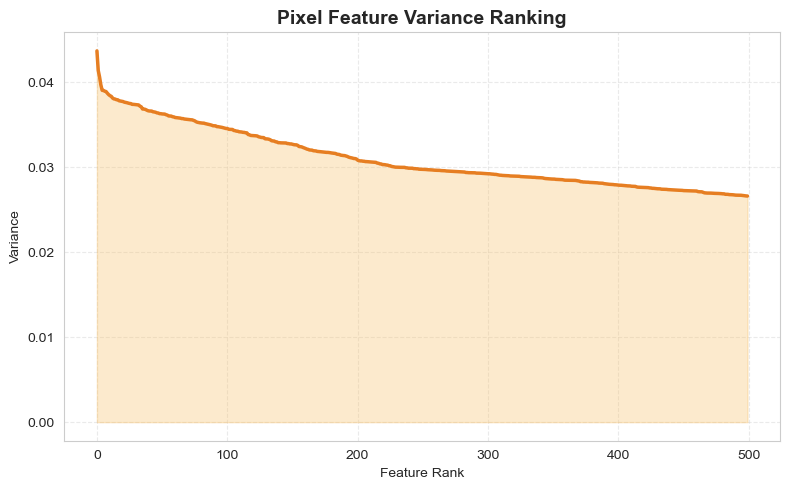

In [116]:
# visualize feature variance

plt.figure(figsize=(8,5))

plt.plot(
    pixel_variance.values[:500],
    color="#E67E22",
    linewidth=2.5
)

plt.fill_between(
    range(500),
    pixel_variance.values[:500],
    color="#F8C471",
    alpha=0.35
)

plt.title(
    "Pixel Feature Variance Ranking",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature Rank")
plt.ylabel("Variance")

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Preprocessing Experiment: Pixel Feature Count

In [117]:
# compare different numbers of top-variance pixel features

pixel_counts = [500, 1000, 2000, 3000]
pixel_exp_results = []

for n in pixel_counts:

    selected_pixels = pixel_variance.index[:n]

    Xn_scaled = StandardScaler().fit_transform(
        X2_raw[selected_pixels]
    )

    Xn_pca = PCA(
        n_components=2,
        random_state=42
    ).fit_transform(Xn_scaled)

    labels_n = KMeans(
        n_clusters=y2.nunique(),
        random_state=42,
        n_init=10
    ).fit_predict(Xn_pca)

    score_n = silhouette_score(
        Xn_pca,
        labels_n
    )

    pixel_exp_results.append([
        n,
        score_n
    ])

pixel_exp_df = pd.DataFrame(
    pixel_exp_results,
    columns=[
        "Top Pixel Features",
        "Silhouette Score"
    ]
)

pixel_exp_df

,Top Pixel Features,Silhouette Score
0,500,0.386059
1,1000,0.379707
2,2000,0.382281
3,3000,0.366373


### Scale Features

In [118]:
# scale selected pixel features

scaler2 = StandardScaler()

X2_scaled = scaler2.fit_transform(X2)

print("Scaled Data Shape:", X2_scaled.shape)

Scaled Data Shape: (400, 2000)


## Clustering Before Dimensionality Reduction

In [119]:
# K-Means on scaled pixel features before dimensionality reduction

n_classes = y2.nunique()

labels_before_dr = KMeans(
    n_clusters=n_classes,
    random_state=42,
    n_init=20
).fit_predict(X2_scaled)

sil_before_dr = silhouette_score(
    X2_scaled,
    labels_before_dr
)

print(
    "Silhouette Score Before Dimensionality Reduction:",
    round(sil_before_dr, 4)
)

Silhouette Score Before Dimensionality Reduction: 0.1352


## Visualization Before Dimensionality Reduction

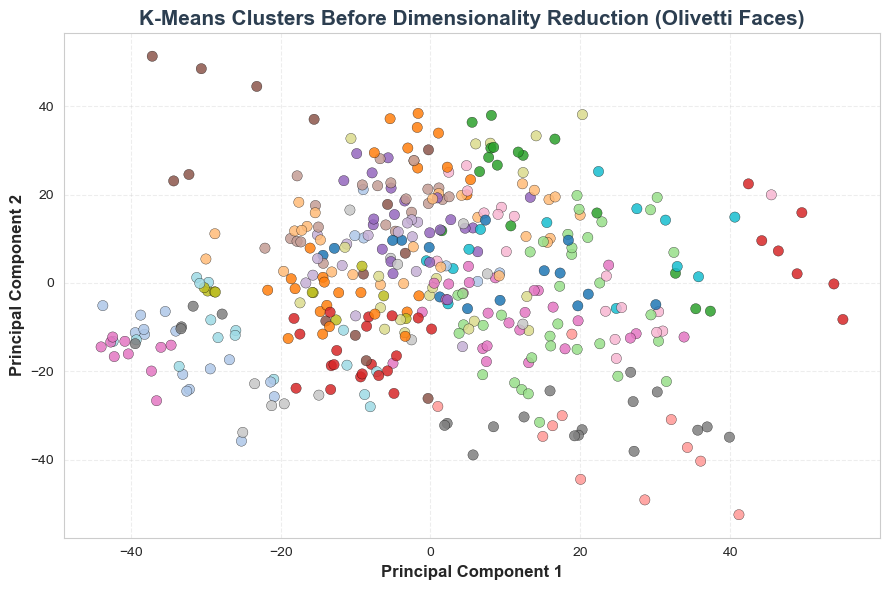

In [120]:
# visualize before dimensionality reduction

viz_proj = PCA(n_components=2, random_state=42).fit_transform(X2_scaled)

plt.figure(figsize=(9,6))

sns.scatterplot(
    x=viz_proj[:,0],
    y=viz_proj[:,1],
    hue=labels_before_dr,
    palette="tab20",
    s=55,
    edgecolor="black",
    linewidth=0.25,
    alpha=0.85,
    legend=False
)

plt.title(
    "K-Means Clusters Before Dimensionality Reduction (Olivetti Faces)",
    fontsize=15,
    fontweight="bold",
    color="#2C3E50"
)

plt.xlabel(
    "Principal Component 1",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Principal Component 2",
    fontsize=12,
    fontweight="bold"
)

plt.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()

plt.show()

# Principal Component Analysis (PCA)

In [121]:
# fit PCA

pca = PCA(n_components=0.95, random_state=42)

X2_pca_full = pca.fit_transform(X2_scaled)

print(f"Original Features : {X2_scaled.shape[1]}")
print(f"Components Kept   : {X2_pca_full.shape[1]}")
print(f"Variance Explained: {pca.explained_variance_ratio_.sum():.4f}")

Original Features : 2000
Components Kept   : 105
Variance Explained: 0.9502


# PCA 2D Visualization

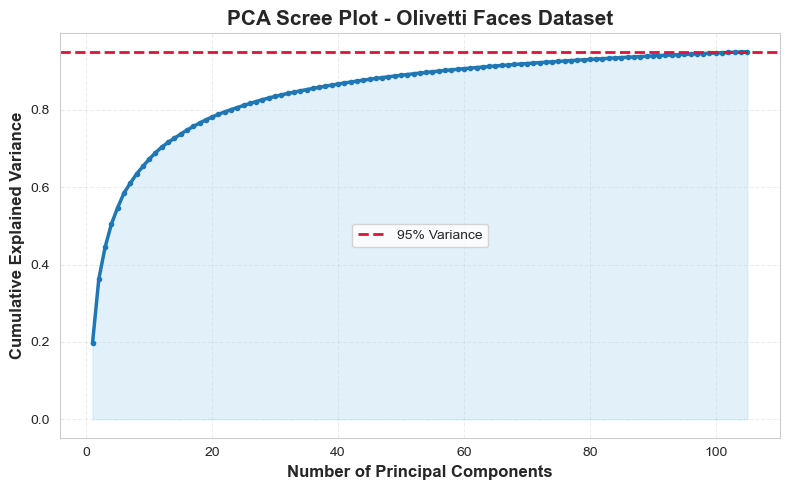

In [122]:
# PCA Scree Plot 

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    color="#1F77B4",
    linewidth=2.5,
    marker="o",
    markersize=3
)

plt.fill_between(
    range(1, len(cum_var)+1),
    cum_var,
    color="#AED6F1",
    alpha=0.35
)

plt.axhline(
    y=0.95,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="95% Variance"
)

plt.xlabel(
    "Number of Principal Components",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Cumulative Explained Variance",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "PCA Scree Plot - Olivetti Faces Dataset",
    fontsize=15,
    fontweight="bold"
)

plt.grid(True, linestyle="--", alpha=0.35)

plt.legend()

plt.tight_layout()

plt.show()

# Kernel PCA (RBF Kernel)

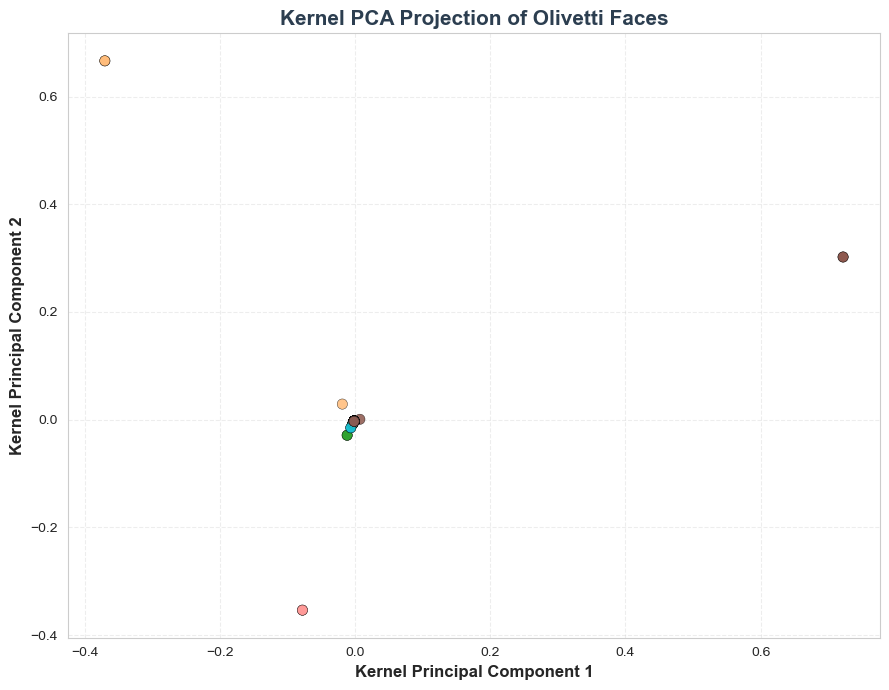

In [123]:
# Kernel PCA (Olivetti Faces)

kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.01,
    random_state=42
)

X2_kpca = kpca.fit_transform(X2_scaled)

plt.figure(figsize=(9,7))

sns.scatterplot(
    x=X2_kpca[:,0],
    y=X2_kpca[:,1],
    hue=y2,
    palette="tab20",
    s=55,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.85,
    legend=False
)

plt.title(
    "Kernel PCA Projection of Olivetti Faces",
    fontsize=15,
    fontweight="bold",
    color="#2C3E50"
)

plt.xlabel(
    "Kernel Principal Component 1",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Kernel Principal Component 2",
    fontsize=12,
    fontweight="bold"
)

plt.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()

plt.show()

# t-SNE

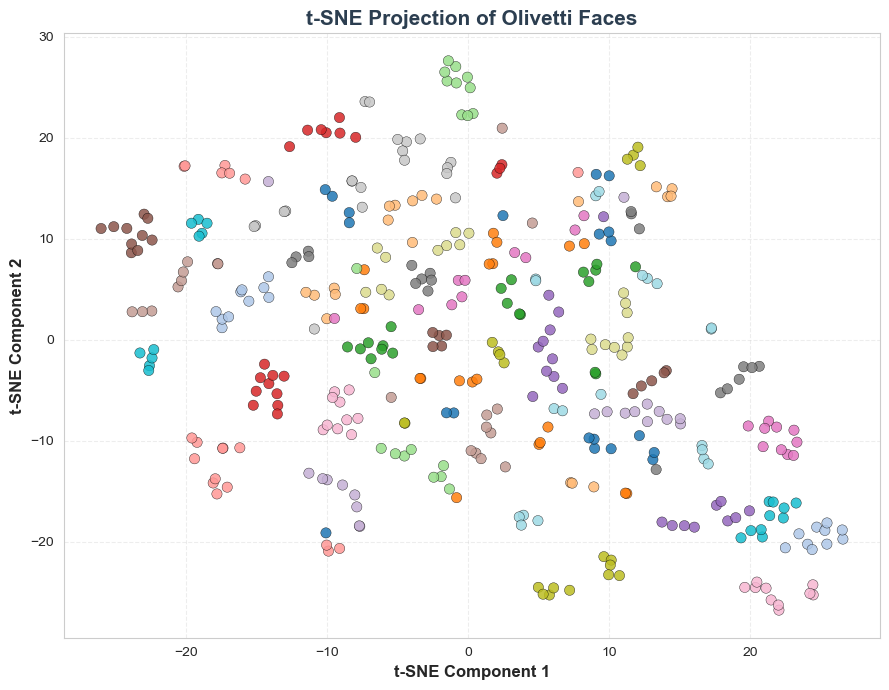

In [124]:
# t-SNE (Olivetti Faces)

tsne = TSNE(
    n_components=2,
    perplexity=35,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X2_tsne = tsne.fit_transform(X2_scaled)

plt.figure(figsize=(9,7))

sns.scatterplot(
    x=X2_tsne[:,0],
    y=X2_tsne[:,1],
    hue=y2,
    palette="tab20",
    s=55,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.85,
    legend=False
)

plt.title(
    "t-SNE Projection of Olivetti Faces",
    fontsize=15,
    fontweight="bold",
    color="#2C3E50"
)

plt.xlabel(
    "t-SNE Component 1",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "t-SNE Component 2",
    fontsize=12,
    fontweight="bold"
)

plt.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()

plt.show()

# t-SNE Parameter Comparison

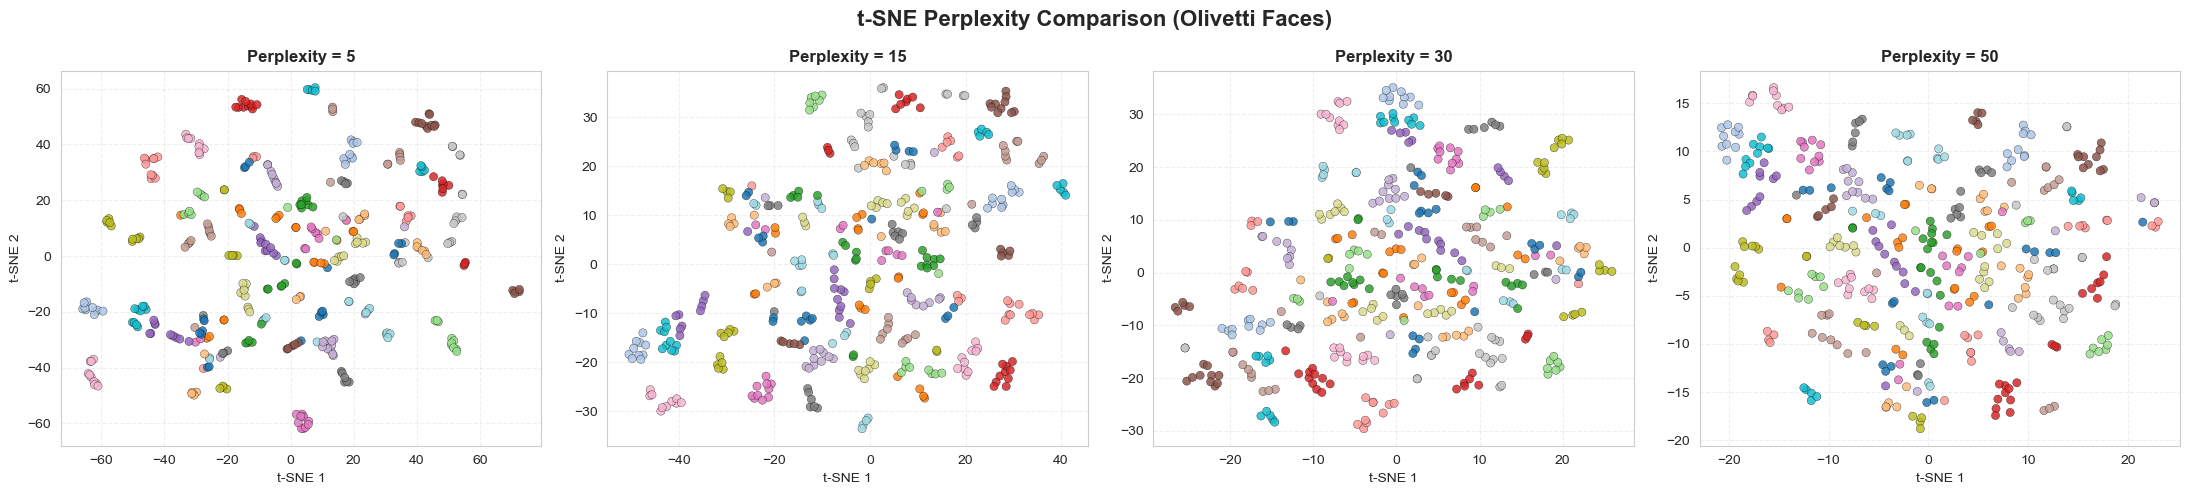

In [125]:
# compare different t-SNE perplexity values

perplexities = [5, 15, 30, 50]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, p in enumerate(perplexities):

    tsne = TSNE(
        n_components=2,
        perplexity=p,
        learning_rate="auto",
        init="pca",
        random_state=42
    )

    X_tsne = tsne.fit_transform(X2_scaled)

    sns.scatterplot(
        x=X_tsne[:, 0],
        y=X_tsne[:, 1],
        hue=y2,
        palette="tab20",
        s=35,
        edgecolor="black",
        linewidth=0.25,
        alpha=0.85,
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Perplexity = {p}",
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_xlabel("t-SNE 1", fontsize=10)
    axes[i].set_ylabel("t-SNE 2", fontsize=10)
    axes[i].grid(True, linestyle="--", alpha=0.3)

plt.suptitle(
    "t-SNE Perplexity Comparison (Olivetti Faces)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# UMAP

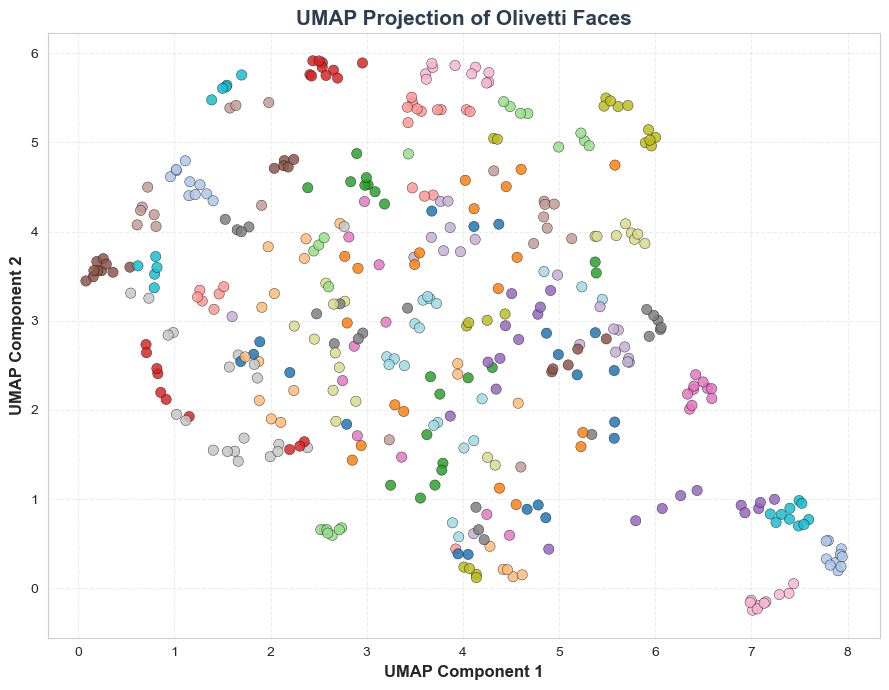

In [126]:
# UMAP projection (Olivetti Faces)

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.15,
    metric="euclidean",
    random_state=42
)

X2_umap = umap_model.fit_transform(X2_scaled)

plt.figure(figsize=(9,7))

sns.scatterplot(
    x=X2_umap[:,0],
    y=X2_umap[:,1],
    hue=y2,
    palette="tab20",
    s=55,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.85,
    legend=False
)

plt.title(
    "UMAP Projection of Olivetti Faces",
    fontsize=15,
    fontweight="bold",
    color="#2C3E50"
)

plt.xlabel(
    "UMAP Component 1",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "UMAP Component 2",
    fontsize=12,
    fontweight="bold"
)

plt.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()

plt.show()

# UMAP Neighbor Comparison

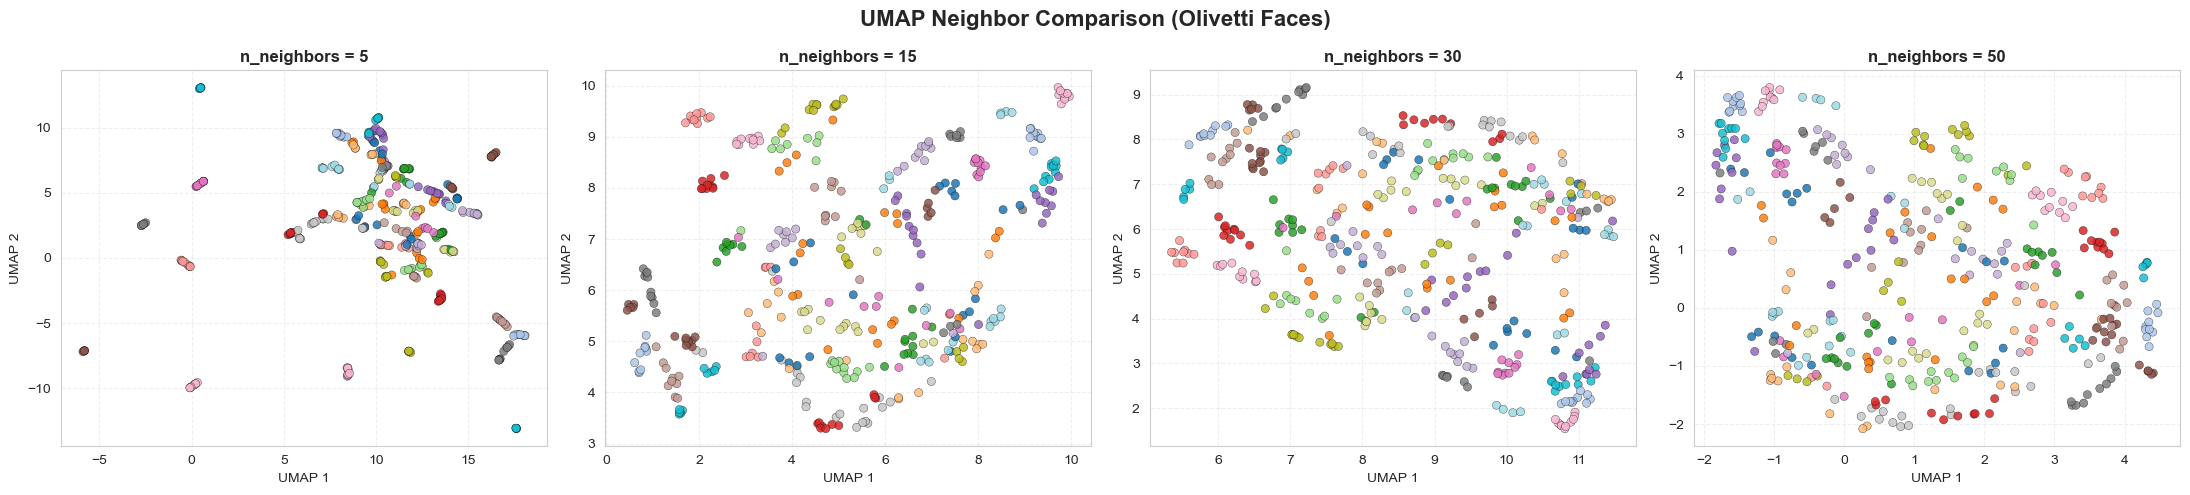

In [127]:
# compare different UMAP neighbor values

neighbors = [5, 15, 30, 50]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, n in enumerate(neighbors):

    um = umap.UMAP(
        n_components=2,
        n_neighbors=n,
        min_dist=0.15,
        metric="cosine",
        random_state=42
    )

    X_umap = um.fit_transform(X2_scaled)

    sns.scatterplot(
        x=X_umap[:, 0],
        y=X_umap[:, 1],
        hue=y2,
        palette="tab20",
        s=35,
        edgecolor="black",
        linewidth=0.25,
        alpha=0.85,
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(
        f"n_neighbors = {n}",
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_xlabel("UMAP 1", fontsize=10)
    axes[i].set_ylabel("UMAP 2", fontsize=10)
    axes[i].grid(True, linestyle="--", alpha=0.3)

plt.suptitle(
    "UMAP Neighbor Comparison (Olivetti Faces)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Clustering on Reduced Data

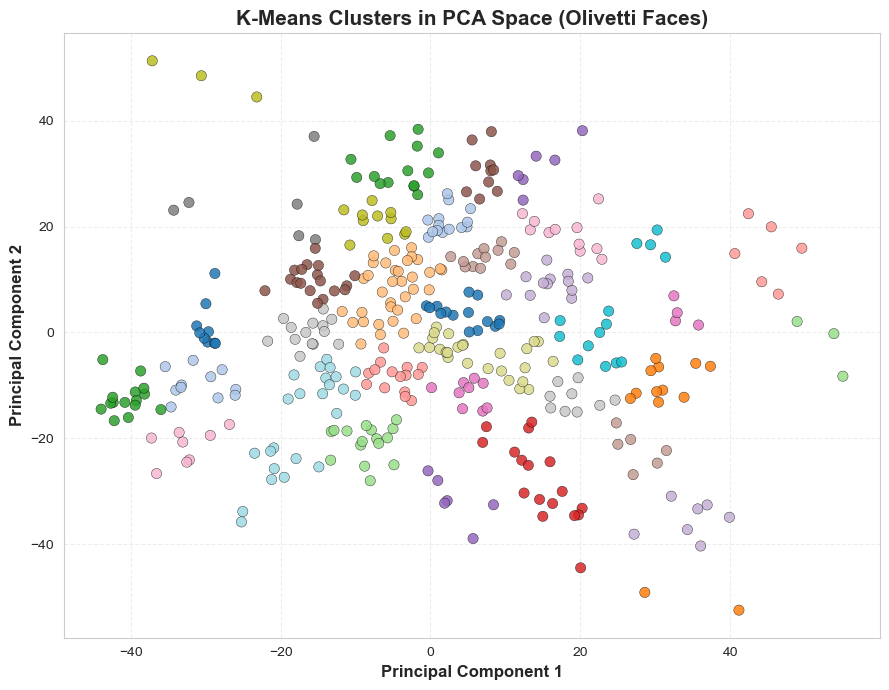

In [128]:
# K-Means clustering on PCA-reduced Olivetti Faces data

n_classes = y2.nunique()

km2 = KMeans(
    n_clusters=n_classes,
    random_state=42,
    n_init=20
)

labels_km2 = km2.fit_predict(X2_pca2)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=X2_pca2[:, 0],
    y=X2_pca2[:, 1],
    hue=labels_km2,
    palette="tab20",
    s=55,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.85,
    legend=False
)

plt.title(
    "K-Means Clusters in PCA Space (Olivetti Faces)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Principal Component 1",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Principal Component 2",
    fontsize=12,
    fontweight="bold"
)

plt.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [129]:
# report clustering summary

print("Number of Clusters:", len(np.unique(labels_km2)))
print("K-Means Inertia:", round(km2.inertia_, 2))

Number of Clusters: 40
K-Means Inertia: 6761.29


# Compare Dimensionality Reduction Methods

In [130]:
# compare dimensionality reduction methods using K-Means clustering

dr_methods = {
    "PCA": X2_pca2,
    "Kernel PCA": X2_kpca,
    "t-SNE": X2_tsne,
    "UMAP": X2_umap
}

dr_results = []

for name, Xr in dr_methods.items():

    km = KMeans(
        n_clusters=len(np.unique(y2)),
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(Xr)

    sil = silhouette_score(Xr, labels)
    db = davies_bouldin_score(Xr, labels)
    ch = calinski_harabasz_score(Xr, labels)

    dr_results.append([name, sil, db, ch])

dr_results_df = pd.DataFrame(
    dr_results,
    columns=[
        "Method",
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz"
    ]
)

dr_results_df

,Method,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,PCA,0.403149,0.716198,3.863572e+02
1,Kernel PCA,0.669526,0.170719,6.093999e+08
2,t-SNE,0.442012,0.688088,5.809034e+02
3,UMAP,0.483593,0.634325,7.626002e+02


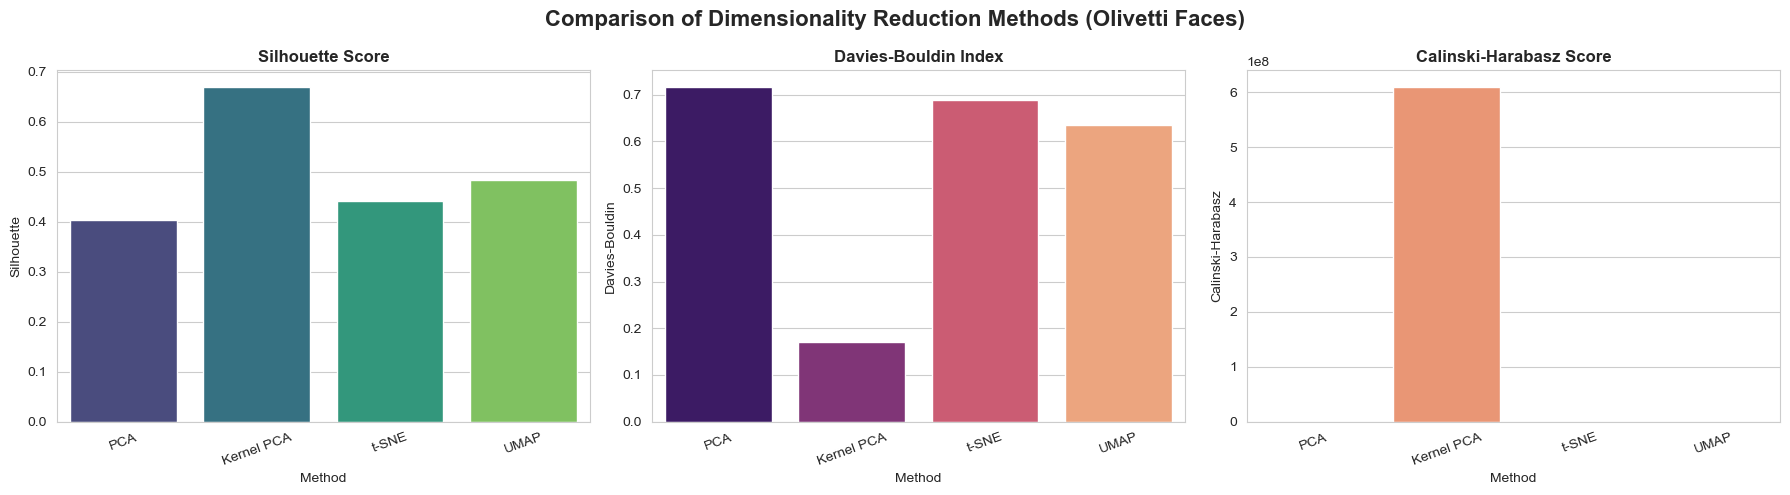

In [131]:
# compare dimensionality reduction methods

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=dr_results_df,
    x="Method",
    y="Silhouette",
    palette="viridis",
    ax=axes[0]
)

axes[0].set_title("Silhouette Score", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=dr_results_df,
    x="Method",
    y="Davies-Bouldin",
    palette="magma",
    ax=axes[1]
)

axes[1].set_title("Davies-Bouldin Index", fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(
    data=dr_results_df,
    x="Method",
    y="Calinski-Harabasz",
    palette="Set2",
    ax=axes[2]
)

axes[2].set_title("Calinski-Harabasz Score", fontweight="bold")
axes[2].tick_params(axis="x", rotation=20)

plt.suptitle(
    "Comparison of Dimensionality Reduction Methods (Olivetti Faces)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [132]:
# best dimensionality reduction method

best_method = dr_results_df.loc[
    dr_results_df["Silhouette"].idxmax(),
    "Method"
]

print("Best Dimensionality Reduction Method:", best_method)

Best Dimensionality Reduction Method: Kernel PCA


# Cluster Purity

In [133]:
# compare predicted clusters with actual face identities

purity_table = pd.crosstab(labels_km2, y2)

purity_table

Person_ID,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
row_0,,,,,,,,,,,,,,,,,,,,,
0,0,0,2,0,0,0,0,0,0,3,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,4,0,0,0,4,0,2,0
2,1,0,0,0,1,0,2,0,0,0,...,0,0,0,0,0,3,0,0,0,0
3,0,2,0,2,1,0,0,0,0,1,...,5,0,0,0,0,0,0,0,0,0
4,0,2,0,1,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
5,0,0,2,0,0,0,0,0,0,0,...,3,0,4,0,1,0,0,0,0,0
6,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,3,0,0,0,0,0
7,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
8,0,0,0,0,0,0,0,3,0,0,...,0,1,0,0,0,0,0,0,0,0


# Model Interpretation

In [134]:
# train classifier for feature interpretation

X_train, X_test, y_train, y_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

print("Test Accuracy:", rf.score(X_test, y_test))

Test Accuracy: 0.95


# Feature Importance

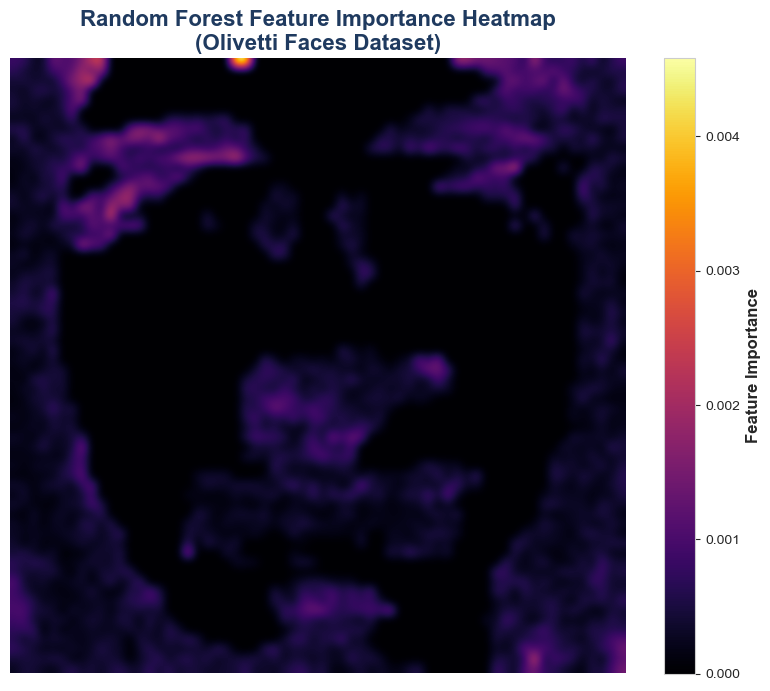

In [139]:
# Random Forest Feature Importance Heatmap 

full_importance = np.zeros(64 * 64)

selected_pixels = X2.columns.astype(int)

full_importance[selected_pixels] = rf.feature_importances_


importance_map = full_importance.reshape(64, 64)

plt.figure(figsize=(8,8))

plt.imshow(
    importance_map,
    cmap="inferno",
    interpolation="bicubic"
)

cbar = plt.colorbar(shrink=0.8)
cbar.set_label(
    "Feature Importance",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "Random Forest Feature Importance Heatmap\n(Olivetti Faces Dataset)",
    fontsize=16,
    fontweight="bold",
    color="#1F3A5F"
)

plt.axis("off")

plt.tight_layout()

plt.show()

# Permutation Importance

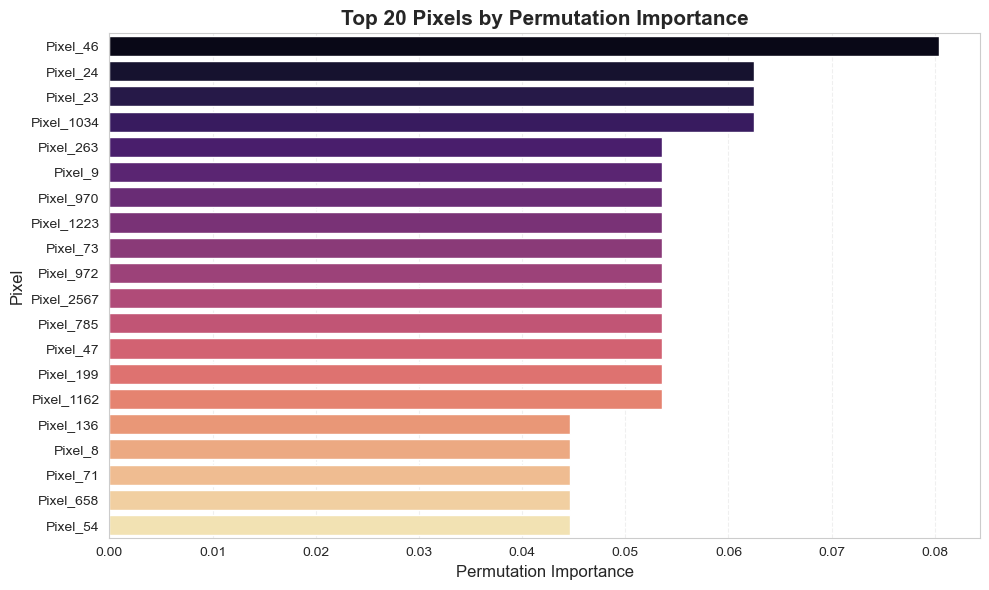

In [145]:
 # faster permutation importance

top_50_indices = np.argsort(rf.feature_importances_)[-50:]

X_test_top50 = X_test.iloc[:, top_50_indices]

rf_top50 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_top50.fit(
    X_train.iloc[:, top_50_indices],
    y_train
)

perm = permutation_importance(
    rf_top50,
    X_test_top50,
    y_test,
    n_repeats=2,
    random_state=42,
    n_jobs=-1,
    max_samples=0.7
)

pixel_names = [
    f"Pixel_{int(X2.columns[i])}"
    for i in top_50_indices
]

perm_series = pd.Series(
    perm.importances_mean,
    index=pixel_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=perm_series.values[:20],
    y=perm_series.index[:20],
    palette="magma"
)

plt.title(
    "Top 20 Pixels by Permutation Importance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Permutation Importance", fontsize=12)
plt.ylabel("Pixel", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# SHAP (Model Interpretation)

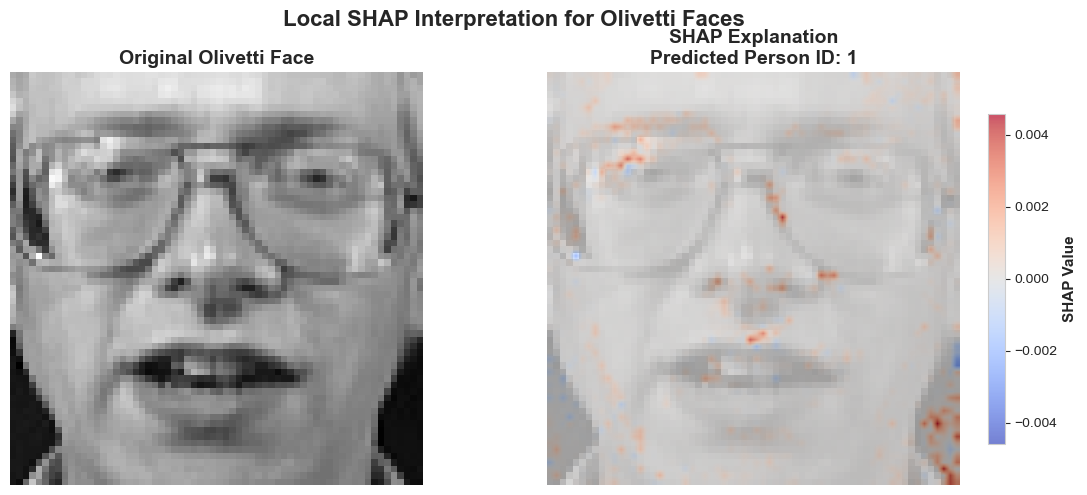

In [143]:

# SHAP explanation overlay for Olivetti Faces
X_sample = X_test.iloc[[0]]

sample_index = X_sample.index[0]

original_face = X2_raw.loc[
    sample_index
].to_numpy().reshape(64, 64)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_sample)

predicted_class = int(rf.predict(X_sample)[0])

class_position = list(rf.classes_).index(predicted_class)

if isinstance(shap_values, list):

    sample_shap = shap_values[class_position][0]

else:

    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:

        sample_shap = shap_array[
            0,
            :,
            class_position
        ]

    elif shap_array.ndim == 2:

        sample_shap = shap_array[0]

    else:

        raise ValueError(
            f"Unexpected SHAP output shape: {shap_array.shape}"
        )

full_shap = np.zeros(64 * 64)

selected_pixel_indices = np.asarray(
    X2.columns,
    dtype=int
)

full_shap[selected_pixel_indices] = sample_shap

shap_map = full_shap.reshape(64, 64)

max_abs_shap = np.max(np.abs(shap_map))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].imshow(
    original_face,
    cmap="gray"
)

axes[0].set_title(
    "Original Olivetti Face",
    fontsize=14,
    fontweight="bold"
)

axes[0].axis("off")

axes[1].imshow(
    original_face,
    cmap="gray"
)

overlay = axes[1].imshow(
    shap_map,
    cmap="coolwarm",
    alpha=0.70,
    interpolation="bilinear",
    vmin=-max_abs_shap,
    vmax=max_abs_shap
)

axes[1].set_title(
    f"SHAP Explanation\nPredicted Person ID: {predicted_class}",
    fontsize=14,
    fontweight="bold"
)

axes[1].axis("off")

cbar = fig.colorbar(
    overlay,
    ax=axes[1],
    shrink=0.80
)

cbar.set_label(
    "SHAP Value",
    fontsize=11,
    fontweight="bold"
)

fig.suptitle(
    "Local SHAP Interpretation for Olivetti Faces",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

  

# Partial Dependence Plots

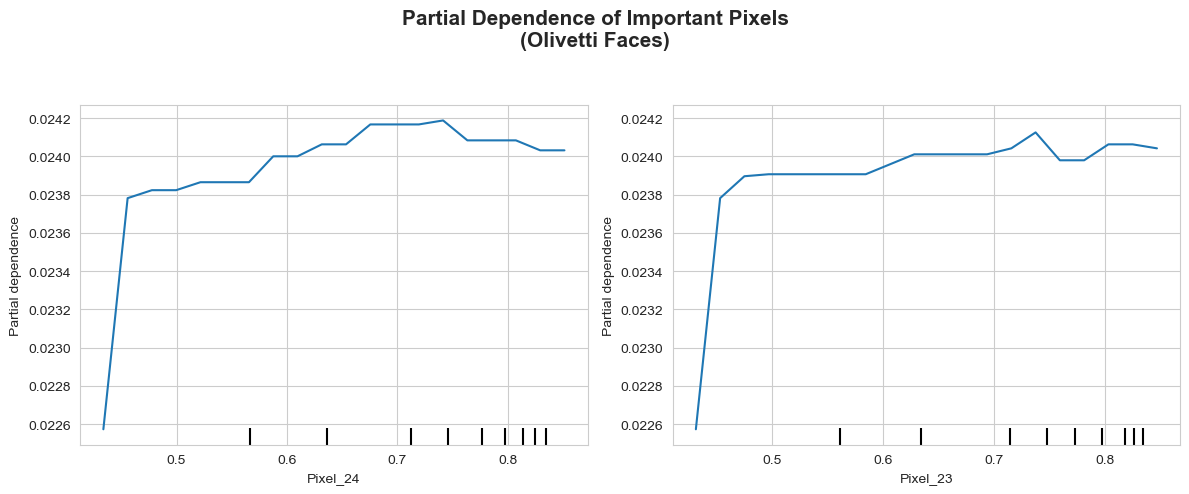

In [144]:
# partial dependence plots for Olivetti Faces

top_feature_positions = np.argsort(
    rf.feature_importances_
)[-2:][::-1]

X_train_pdp = X_train.to_numpy(dtype=np.float64)

feature_names = [
    f"Pixel_{int(column)}"
    for column in X2.columns
]

fig, ax = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

PartialDependenceDisplay.from_estimator(
    rf,
    X_train_pdp,
    features=top_feature_positions.tolist(),
    target=rf.classes_[0],
    feature_names=feature_names,
    method="brute",
    grid_resolution=20,
    ax=ax
)

fig.suptitle(
    "Partial Dependence of Important Pixels\n(Olivetti Faces)",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()